# Exercise 06: Wikipedia Vote Network

Erdős–Rényi null model comparison for the Wikipedia admin-election vote network.

In [1]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import random

## Load Data

**Citation:** J. Leskovec, D. Huttenlocher, and J. Kleinberg. Signed networks in social media. CHI 2010.

In [2]:
data_path = Path('data/wiki-Vote.txt')
G = nx.DiGraph()

with open(data_path, 'r') as f:
    for line in f:
        line = line.strip()
        if line.startswith('#'):
            continue
        if not line:
            continue
        parts = line.split('\t')
        if len(parts) >= 2:
            u, v = int(parts[0]), int(parts[1])
            G.add_edge(u, v)

n = G.number_of_nodes()
m = G.number_of_edges()
density = m / (n * (n - 1))
max_in  = max(d for _, d in G.in_degree())
max_out = max(d for _, d in G.out_degree())

print(f'Nodes: {n}, Edges: {m}')
print(f'Density: {density:.6f}')
print(f'Avg in/out-degree: {m / n:.2f}')
print(f'Max in-degree: {max_in}, Max out-degree: {max_out}')

Nodes: 7115, Edges: 103689
Density: 0.002049
Avg in/out-degree: 14.57
Max in-degree: 457, Max out-degree: 893


## Build Directed ER Baseline

`p = m / (n*(n-1))` is the directed density — the denominator is the number of possible directed edges (ordered pairs, no self-loops).

In [3]:
p = m / (n * (n - 1))
ER = nx.erdos_renyi_graph(n, p, directed=True, seed=42)

n_er     = ER.number_of_nodes()
m_er     = ER.number_of_edges()
max_in_er  = max(d for _, d in ER.in_degree())
max_out_er = max(d for _, d in ER.out_degree())

print(f'ER: {n_er} nodes, {m_er} edges')
print(f'Edge count difference: {m_er - m:+d} ({100*(m_er - m)/m:.1f}%)')
print(f'ER avg in/out-degree: {m_er / n_er:.2f}')
print(f'ER max in-degree: {max_in_er}, max out-degree: {max_out_er}')

ER: 7115 nodes, 103530 edges
Edge count difference: -159 (-0.2%)
ER avg in/out-degree: 14.55
ER max in-degree: 31, max out-degree: 32


## Direction-Aware Degree Distributions

In-degree and out-degree are plotted separately on a log-y scale. The real network's heavy tail — a small number of highly-voted pages and prolific voters — stands in sharp contrast to the ER Poisson distribution concentrated near the mean.

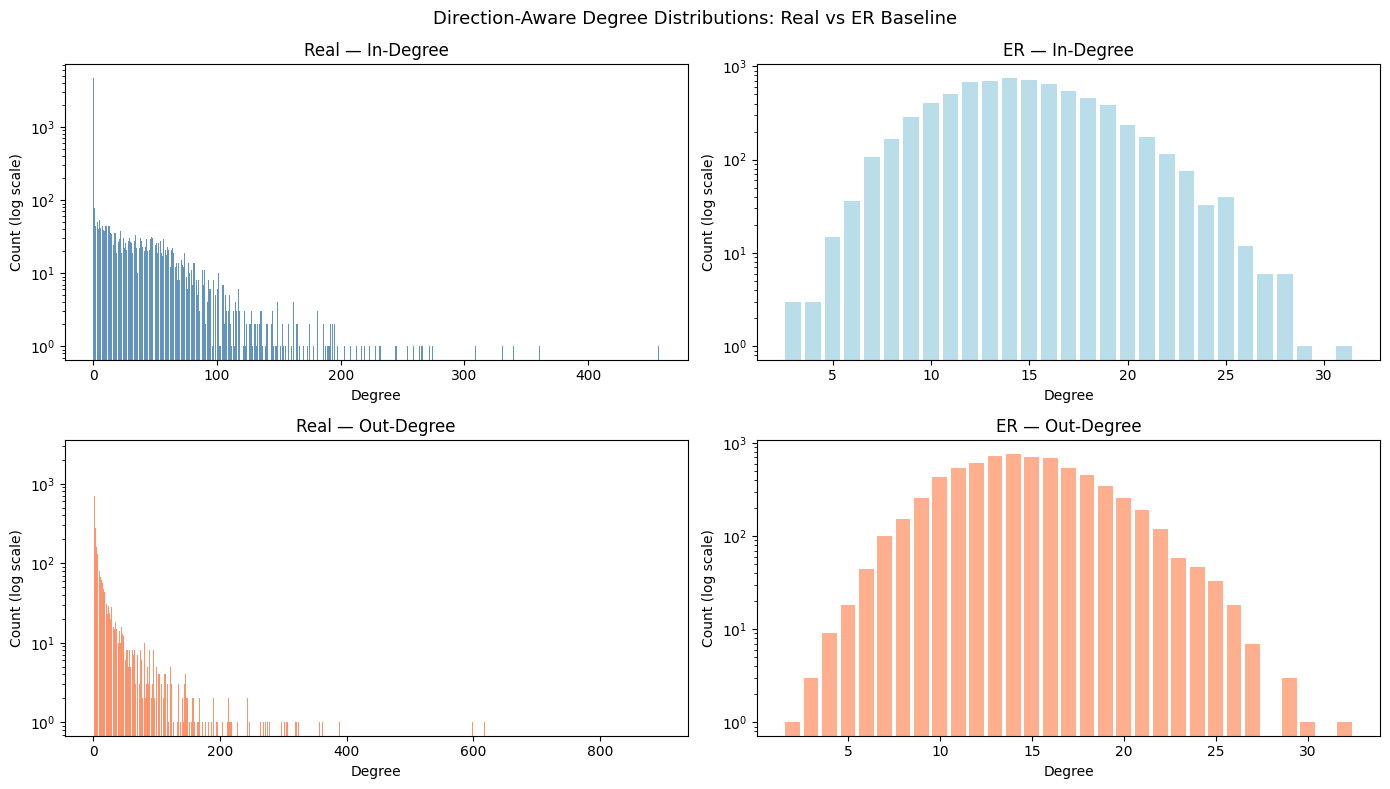

In [4]:
in_deg_real  = Counter(d for _, d in G.in_degree())
out_deg_real = Counter(d for _, d in G.out_degree())
in_deg_er    = Counter(d for _, d in ER.in_degree())
out_deg_er   = Counter(d for _, d in ER.out_degree())

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Direction-Aware Degree Distributions: Real vs ER Baseline', fontsize=13)

panels = [
    (axes[0, 0], in_deg_real,  'Real — In-Degree',  'steelblue'),
    (axes[0, 1], in_deg_er,    'ER — In-Degree',    'lightblue'),
    (axes[1, 0], out_deg_real, 'Real — Out-Degree', 'coral'),
    (axes[1, 1], out_deg_er,   'ER — Out-Degree',   'lightsalmon'),
]

for ax, deg_counts, title, color in panels:
    degs = sorted(deg_counts.keys())
    cnts = [deg_counts[d] for d in degs]
    ax.bar(degs, cnts, color=color, alpha=0.85, width=0.8)
    ax.set_yscale('log')
    ax.set_xlabel('Degree')
    ax.set_ylabel('Count (log scale)')
    ax.set_title(title)

plt.tight_layout()
plt.savefig('degree_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Clustering Coefficient

`nx.average_clustering(G)` on a `DiGraph` computes the directed clustering coefficient (Fagiolo 2007), counting directed triangles through each node. For ER, theory predicts C ≈ p.

In [ ]:
clust_real = nx.average_clustering(G)
clust_er   = nx.average_clustering(ER)

print(f'Real graph clustering:  {clust_real:.4f}')
print(f'ER baseline clustering: {clust_er:.4f}')
print(f'Theoretical ER (C = p): {p:.6f}')

## Average Path Length on Giant WCC

Directed APL requires strong connectivity; the Wikipedia vote SCC covers only ~18% of nodes. APL is computed on the giant **weakly connected** component (undirected), consistent with the weak-connectivity focus for this network.

500 randomly sampled source nodes give a reliable estimate while keeping runtime tractable.

In [ ]:
WCC_nodes_real = max(nx.weakly_connected_components(G), key=len)
G_wcc_real = G.subgraph(WCC_nodes_real).to_undirected()

WCC_nodes_er = max(nx.weakly_connected_components(ER), key=len)
G_wcc_er = ER.subgraph(WCC_nodes_er).to_undirected()

def sampled_apl(graph, sample_size=500, seed=42):
    random.seed(seed)
    nodes = list(graph.nodes)
    sample = random.sample(nodes, min(sample_size, len(nodes)))
    lengths = []
    for source in sample:
        spl = nx.single_source_shortest_path_length(graph, source)
        lengths.extend(v for k, v in spl.items() if k != source)
    return np.mean(lengths)

apl_real = sampled_apl(G_wcc_real)
apl_er   = sampled_apl(G_wcc_er)

print(f'APL on giant WCC (500-node sample):')
print(f'  Real graph:  {apl_real:.3f}')
print(f'  ER baseline: {apl_er:.3f}')

APL on giant WCC (500-node sample):
  Real graph:  3.238
  ER baseline: 2.922


## Connected Component Sizes

WCC vs SCC gap reveals directional asymmetry: most votes are not reciprocated, so mutual reachability along directed edges is confined to a small core.

In [ ]:
wcc_real = len(max(nx.weakly_connected_components(G), key=len))
scc_real = len(max(nx.strongly_connected_components(G), key=len))
wcc_er   = len(max(nx.weakly_connected_components(ER), key=len))
scc_er   = len(max(nx.strongly_connected_components(ER), key=len))

print(f'Giant WCC: real={wcc_real} ({100*wcc_real/n:.1f}%), ER={wcc_er} ({100*wcc_er/n:.1f}%)')
print(f'Giant SCC: real={scc_real} ({100*scc_real/n:.1f}%), ER={scc_er} ({100*scc_er/n:.1f}%)')

Giant WCC: real=7066 (99.3%), ER=7115 (100.0%)
Giant SCC: real=1300 (18.3%), ER=7115 (100.0%)


## Comparison Table

In [ ]:
rows = {
    'Metric': [
        'Nodes', 'Edges', 'Density',
        'Avg in-degree', 'Avg out-degree',
        'Max in-degree', 'Max out-degree',
        'Clustering coefficient',
        'Avg path length (WCC sample)',
        'Giant WCC (%)', 'Giant SCC (%)'
    ],
    'Real (Wiki-Vote)': [
        n, m, f'{density:.6f}',
        f'{m/n:.2f}', f'{m/n:.2f}',
        max_in, max_out,
        f'{clust_real:.4f}',
        f'{apl_real:.3f}',
        f'{100*wcc_real/n:.1f}%',
        f'{100*scc_real/n:.1f}%'
    ],
    'ER Baseline': [
        n_er, m_er, f'{m_er/(n_er*(n_er-1)):.6f}',
        f'{m_er/n_er:.2f}', f'{m_er/n_er:.2f}',
        max_in_er, max_out_er,
        f'{clust_er:.4f}',
        f'{apl_er:.3f}',
        f'{100*wcc_er/n_er:.1f}%',
        f'{100*scc_er/n_er:.1f}%'
    ]
}

df = pd.DataFrame(rows)
print(df.to_string(index=False))

                      Metric Real (Wiki-Vote) ER Baseline
                       Nodes             7115        7115
                       Edges           103689      103530
                     Density         0.002049    0.002045
               Avg in-degree            14.57       14.55
              Avg out-degree            14.57       14.55
               Max in-degree              457          31
              Max out-degree              893          32
      Clustering coefficient           0.0816      0.0020
Avg path length (WCC sample)            3.238       2.922
               Giant WCC (%)            99.3%      100.0%
               Giant SCC (%)            18.3%      100.0%


## Conclusion

The Wikipedia vote network differs strongly from the ER random baseline on three key properties:

**Heavy-tailed in/out-degree (non-random):** The ER baseline produces Poisson-distributed in/out-degrees concentrated near the mean (14.57). The real network has a heavy tail — the most-voted page received 457 votes (vs. max 31 in ER) and the most active voter cast 893 votes (vs. max 32 in ER). Reputation and preferential attention, not chance, drive this structure.

**Higher clustering (non-random):** The real network's directed clustering coefficient is 40× higher than the ER baseline (0.082 vs. 0.002, matching the theoretical prediction C ≈ p). Voters form cohesive groups that tend to vote for each other — a social pattern absent in random wiring.

**Large WCC / small SCC gap (non-random):** Both networks have a large WCC (≥99%), but the real network's SCC covers only 18.3% of nodes vs. 100% for ER. Voting is directionally asymmetric: most votes are not reciprocated, and mutual reachability along directed edges is confined to a small core. Random direction assignment in ER creates a fully-connected SCC at this density, which the real voting dynamic never produces.

**Average path length (matches ER):** Both networks are small-world — APL is 3.24 for the real graph and 2.92 for ER. Path length is not a discriminating feature here; it is explained by chance alone.